Using device: cuda


C:\Users\puliu\AppData\Local\Temp\ipykernel_23888\3705984716.py:87: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("deeplabv3_final.pth", map

✅ Model loaded
🔄 Evaluating dataset (1000 images)...


Evaluation: 100%|█████████████████████████████████████████████████████████████████| 250/250 [01:53<00:00,  2.20batch/s]



📊 Metrics -> Mean IoU: 0.8664, Mean Dice: 0.9181, Accuracy: 0.9531

🎨 Showing 5 random samples...



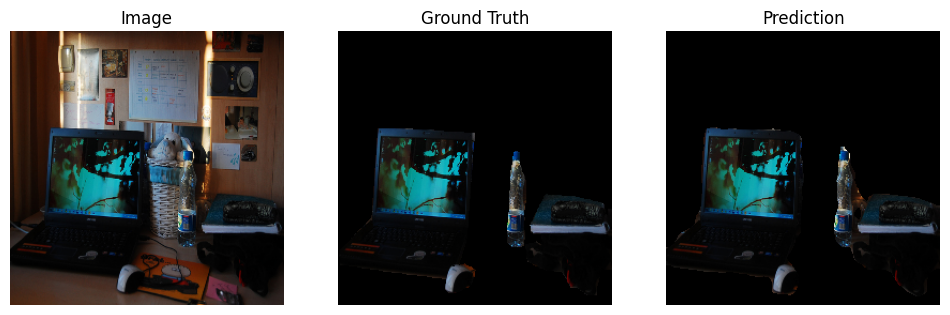

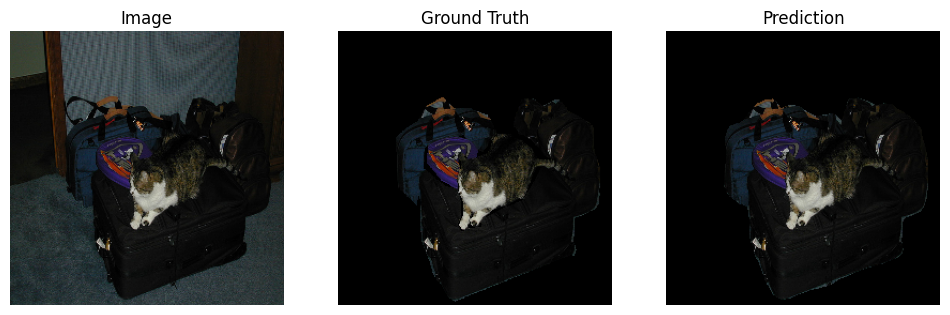

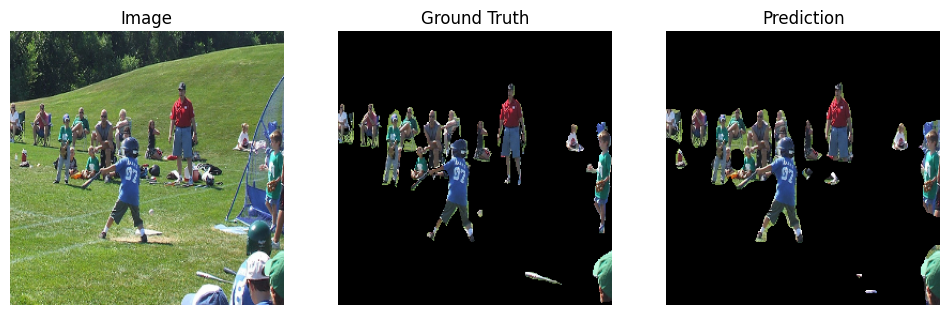

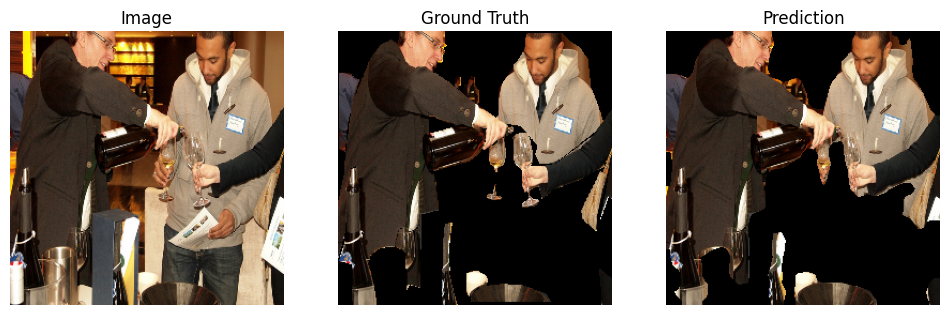

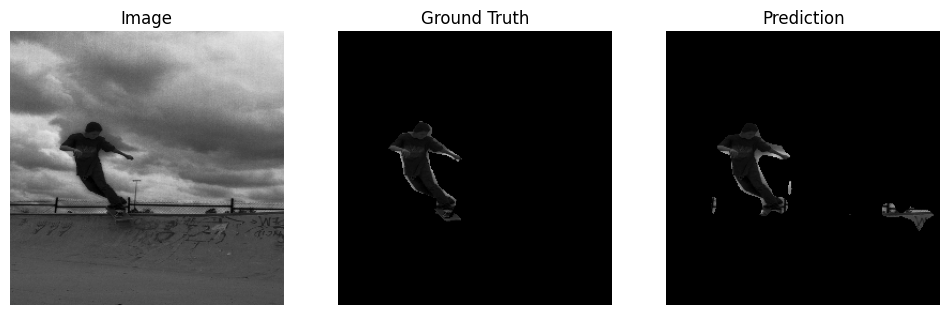

In [1]:
import os
import json
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
import matplotlib.pyplot as plt
from skimage.draw import polygon
from tqdm import tqdm

# ================= Device =================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ================= Dataset =================
class CocoMaskedDataset(Dataset):
    def __init__(self, images_path, annotations_path, transform=None):
        with open(annotations_path, "r") as f:
            coco = json.load(f)
        self.images_path = images_path
        self.images = {img["id"]: img["file_name"] for img in coco["images"]}
        self.image_ids = list(self.images.keys())
        self.annotations = {}
        for ann in coco["annotations"]:
            img_id = ann["image_id"]
            if img_id not in self.annotations:
                self.annotations[img_id] = []
            self.annotations[img_id].append(ann)
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img = np.array(Image.open(os.path.join(self.images_path, self.images[img_id])).convert("RGB"))
        mask = np.zeros(img.shape[:2], dtype=np.uint8)
        for ann in self.annotations.get(img_id, []):
            for seg in ann.get("segmentation", []):
                if isinstance(seg, list) and len(seg) % 2 == 0:
                    poly_pts = np.array(seg).reshape(-1, 2)
                    rr, cc = polygon(poly_pts[:, 1], poly_pts[:, 0], shape=img.shape[:2])
                    mask[rr, cc] = 1
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented["image"], augmented["mask"]
        return img.float(), mask.long()

# ================= Transforms =================
val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])

# ================= Paths =================
images_path = r"D:\val2017\val2017"
annotations_path = r"D:\annotations_trainval2017\annotations\instances_val2017.json"

val_dataset = CocoMaskedDataset(images_path, annotations_path, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

# ---- Subset validation set to 1000 images ----
val_subset = Subset(val_dataset, range(1000))
val_loader_small = DataLoader(val_subset, batch_size=4, shuffle=False)

# ================= Model =================
num_classes = 2
weights = DeepLabV3_ResNet50_Weights.DEFAULT
model = deeplabv3_resnet50(weights=weights, aux_loss=True)

# Modify classifier
old_cls = model.classifier
model.classifier = nn.Sequential(
    old_cls[0], old_cls[1], old_cls[2], nn.Dropout(0.3),
    nn.Conv2d(256, 128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.Conv2d(128, num_classes, kernel_size=1)
)
model = model.to(device)
model.load_state_dict(torch.load("deeplabv3_final.pth", map_location=device))
model.eval()
print("Model loaded")

# ================= Metrics =================
def compute_metrics(preds, masks, num_classes):
    ious, dices = [], []
    correct, total = 0, 0
    for pred, mask in zip(preds, masks):
        for cls in range(num_classes):
            pred_cls = (pred == cls)
            mask_cls = (mask == cls)
            intersection = (pred_cls & mask_cls).sum()
            union = (pred_cls | mask_cls).sum()
            if union > 0:
                ious.append(intersection / union)
            if (pred_cls.sum() + mask_cls.sum()) > 0:
                dices.append((2 * intersection) / (pred_cls.sum() + mask_cls.sum()))
        correct += (pred == mask).sum()
        total += mask.size
    return np.mean(ious), np.mean(dices), correct / total

# ================= Evaluation & Visualization =================
def evaluate_and_visualize(model, dataset, loader, num_classes, num_samples=5):
    model.eval()
    all_preds, all_masks = [], []

    # ---- Compute Metrics with progress bar ----
    print(f"Evaluating dataset ({len(loader.dataset)} images)...")
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Evaluation", unit="batch"):
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)['out']
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            masks_np = masks.cpu().numpy()
            all_preds.extend(preds)
            all_masks.extend(masks_np)

    mean_iou, mean_dice, acc = compute_metrics(all_preds, all_masks, num_classes)
    print(f"\nMetrics -> Mean IoU: {mean_iou:.4f}, Mean Dice: {mean_dice:.4f}, Accuracy: {acc:.4f}\n")

    # ---- Random Visualization ----
    print(f"Showing {num_samples} random samples...\n")
    indices = random.sample(range(len(dataset)), num_samples)

    for idx in indices:
        img, mask_gt = dataset[idx]
        img_in = img.unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(img_in)['out']
        pred = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

        # Denormalize image
        img_vis = img.permute(1, 2, 0).cpu().numpy()
        img_vis = img_vis * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
        img_vis = np.clip(img_vis, 0, 1)

        # Highlight only object
        highlighted_gt = img_vis * np.expand_dims(mask_gt.numpy(), axis=-1)
        highlighted_pred = img_vis * np.expand_dims(pred, axis=-1)

        # Plot
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1); plt.imshow(img_vis); plt.title("Image"); plt.axis("off")
        plt.subplot(1, 3, 2); plt.imshow(highlighted_gt); plt.title("Ground Truth"); plt.axis("off")
        plt.subplot(1, 3, 3); plt.imshow(highlighted_pred); plt.title("Prediction"); plt.axis("off")
        plt.show()

# ================= Run Evaluation on Subset =================
evaluate_and_visualize(model, val_dataset, val_loader_small, num_classes=num_classes, num_samples=5)
